# HRNet Landmark Detection Training

This notebook trains a high-resolution network (HRNet) using `timm` as the backbone to detect 8 cephalometric facial keypoints.

In [1]:
import os
import sys
import json
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import timm
    
# Add cloned HRNet repo to Python path to import their official functions
sys.path.append('HRNet-Facial-Landmark-Detection')

from lib.utils.transforms import crop_v2, generate_target, transform_pixel
from lib.core.evaluation import decode_preds, compute_nme

# Setup device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


/home/nhatnm/code/myprojects/ceph-landmark-detection/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load Dataset and Visualize a Test Sample

ann_file = "coco_annotations.json"
img_dir = "data/"

# Custom Dataset Using Official HRNet Transforms
class CephalometricDataset(Dataset):
    def __init__(self, annotation_file, img_dir, is_train=True, image_size=(512, 512), heatmap_size=(128, 128), sigma=2.0):
        with open(annotation_file, 'r', encoding='utf-8') as f:
            self.coco = json.load(f)
            
        self.img_dir = img_dir
        self.is_train = is_train
        # Usually HRNet defines image_size as [W, H]
        self.image_size = list(image_size) 
        self.heatmap_size = list(heatmap_size)
        self.sigma = sigma
        
        # Augmentation Factors
        self.scale_factor = 0.25
        self.rot_factor = 30
        self.flip = True
        
        # Create image_id to file_name mapping
        self.images = {img['id']: img for img in self.coco['images']}
        
        # Filter annotations to only those where the image exists
        valid_annotations = []
        for ann in self.coco['annotations']:
            img_info = self.images[ann['image_id']]
            img_path = os.path.join(self.img_dir, img_info['file_name'])
            if os.path.exists(img_path):
                valid_annotations.append(ann)
            else:
                print(f"Warning: Image not found, skipping {img_path}")
                
        self.annotations = valid_annotations
        
        self.mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
        self.std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
        
    def __len__(self):
        return len(self.annotations)
        
    def __getitem__(self, idx):
        ann = self.annotations[idx]
        img_info = self.images[ann['image_id']]
        
        # 1. Load Image
        img_path = os.path.join(self.img_dir, img_info['file_name'])
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # 2. Extract Keypoints and Reshape
        keypoints = ann['keypoints']
        pts = np.array(keypoints).reshape(-1, 3) # [8, 3] -> (x, y, v)
        
        # -------------------------------------------------------------
        # FIX: Use the entire image as the bounding box to match Inference!
        # Previously we extracted `ann['bbox']` which was too tight.
        # Medical cephalograms are fixed format, whole image context helps.
        # -------------------------------------------------------------
        orig_w = img_info['width']
        orig_h = img_info['height']
        center_w = orig_w / 2.0
        center_h = orig_h / 2.0
        center = np.array([center_w, center_h], dtype=np.float32)
        
        scale = max(orig_w, orig_h) / 200.0 * 1.25
        
        r = 0
        if self.is_train:
            # 1. Random Scale Augmentation
            scale = scale * random.uniform(1 - self.scale_factor, 1 + self.scale_factor)
            
            # 2. Random Rotation Augmentation
            if random.random() <= 0.6:
                r = random.uniform(-self.rot_factor, self.rot_factor)
                
            # 3. Random Horizontal Flip Augmentation
            if random.random() <= 0.5 and self.flip:
                # Flip image horizontally
                image = cv2.flip(image, 1)
                
                # Flip center horizontally
                img_width = image.shape[1]
                center[0] = img_width - center[0] - 1
                
                # Flip landmarks horizontally
                # Because cephalometric landmarks are single midline points, we don't swap left/right labels
                for i in range(pts.shape[0]):
                    if pts[i, 2] > 0:
                        pts[i, 0] = img_width - pts[i, 0] - 1

        # 3. Apply Affine Crop using OpenCV specifically
        img_crop = crop_v2(image, center, scale, self.image_size, rot=r)
        
        # 4. Transform Keypoints and Generate Targets
        nparts = pts.shape[0]
        target = np.zeros((nparts, self.heatmap_size[1], self.heatmap_size[0]), dtype=np.float32)
        target_weight = np.ones((nparts, 1), dtype=np.float32)
        tpts = pts.copy()
        
        for i in range(nparts):
            if tpts[i, 2] > 0: # If visible
                # Transform point from original image to crop-scale, then to heatmap-scale
                tpts[i, 0:2] = transform_pixel(tpts[i, 0:2] + 1, center, scale, self.heatmap_size, rot=r)
                
                # generate_target expects [num_keypoints, H, W]
                target[i] = generate_target(target[i], tpts[i, 0:2] - 1, self.sigma, label_type='Gaussian')
            else:
                tpts[i, 0:2] = -1
                target_weight[i] = 0

        # 5. Normalize
        img_crop = img_crop.astype(np.float32)
        img_crop = (img_crop / 255.0 - self.mean) / self.std
        img_crop = img_crop.transpose([2, 0, 1])
        
        img_tensor = torch.from_numpy(img_crop)
        target_tensor = torch.from_numpy(target)
        target_weight = torch.from_numpy(target_weight)
        
        # Keep meta information for exact coordinate decoding later
        meta = {
            'index': idx,
            'center': torch.Tensor(center),
            'scale': scale,
            'pts': torch.Tensor(pts[:, :2]),
            'tpts': torch.Tensor(tpts[:, :2])
        }
        
        return img_tensor, target_tensor, target_weight, meta

Dataset successfully loaded. Total samples: 55
3.761520858064956


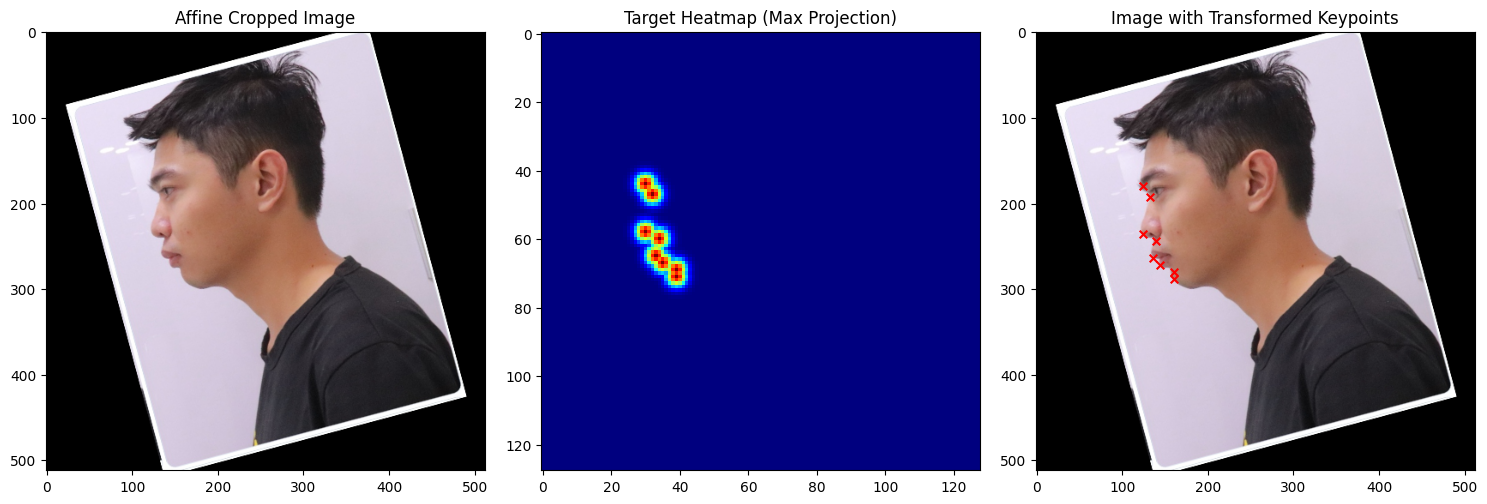

In [3]:


dataset = CephalometricDataset(ann_file, img_dir, image_size=[512, 512], heatmap_size=[128, 128])
print(f"Dataset successfully loaded. Total samples: {len(dataset)}")

# Get first sample
img_tensor, hm_tensor, hm_weight, meta = dataset[1]

# Denormalize image for viewing
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
img_show = (img_tensor * std) + mean
img_show = img_show.permute(1, 2, 0).numpy()
img_show = np.clip(img_show, 0, 1)

# Set up Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_show)
axes[0].set_title("Affine Cropped Image")

# Combine target heatmaps
combined_hm = torch.max(hm_tensor, dim=0)[0].numpy()
axes[1].imshow(combined_hm, cmap='jet')
axes[1].set_title("Target Heatmap (Max Projection)")

# Overlay Transformed Points
axes[2].imshow(img_show)
axes[2].set_title("Image with Transformed Keypoints")

# Plot points mapped correctly
tpts = meta['tpts'].numpy()
for i in range(8):
    if hm_weight[i] > 0:
        # Multiply by 4 since the heatmaps are 128x128 but image is 512x512
        axes[2].scatter(tpts[i][0] * 4, tpts[i][1] * 4, s=30, c='red', marker='x')

plt.tight_layout()
plt.show()

In [4]:
import torch.nn.functional as F

class PoseHRNet(nn.Module):
    def __init__(self, num_keypoints=8, pretrained_path='models/hrnetv2_w18_imagenet_pretrained.pth'):
        super(PoseHRNet, self).__init__()
        
        # Load hrnet_w18 from timm WITHOUT features_only.
        # This gives us the full HRNet object.
        self.backbone = timm.create_model('hrnet_w18', pretrained=False)
        
        # Manually load the local pre-trained weights
        if os.path.exists(pretrained_path):
            state_dict = torch.load(pretrained_path, map_location='cpu')
            self.backbone.load_state_dict(state_dict, strict=False)
            print(f"✅ Successfully loaded local pre-trained weights from: {pretrained_path}")
        else:
            print(f"⚠️ Warning: Pre-trained weights not found at {pretrained_path}. Training from scratch!")
            
        # For Facial Landmark Detection, the HRNet authors concatenate the multi-resolution 
        # outputs from the last stage (which has 4 resolutions: [18, 36, 72, 144] channels).
        out_channels_sum = 18 + 36 + 72 + 144
        
        self.final_head = nn.Sequential(
            nn.Conv2d(out_channels_sum, out_channels_sum, kernel_size=1, stride=1, padding=0),
            nn.BatchNorm2d(out_channels_sum),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels_sum, num_keypoints, kernel_size=1, stride=1, padding=0)
        )
        
    def forward(self, x):
        # Retrieve the multi-resolution features manually from timm's backbone
        # We process stem first
        x = self.backbone.conv1(x)
        x = self.backbone.bn1(x)
        x = self.backbone.act1(x)
        x = self.backbone.conv2(x)
        x = self.backbone.bn2(x)
        x = self.backbone.act2(x)
        
        # Then pass through stages (this directly returns the List of 4 resolution branches)
        hr_features = self.backbone.stages(x)
        
        # Up-sample all resolutions to the highest resolution (hr_features[0])
        h, w = hr_features[0].shape[2:]
        out = [hr_features[0]]
        for i in range(1, len(hr_features)):
            out.append(F.interpolate(hr_features[i], size=(h, w), mode='bilinear', align_corners=False))
            
        # Concatenate and pass through the final linear projection to heatmaps
        out_cat = torch.cat(out, dim=1) # Shape: (B, 270, 128, 128)
        heatmaps = self.final_head(out_cat)
        
        return heatmaps

# Initialize and verify local weights are loaded
model = PoseHRNet(num_keypoints=8, pretrained_path='models/hrnetv2_w18_imagenet_pretrained.pth').to(device)

# Test dummy pass to confirm shapes
dummy_input = torch.randn(1, 3, 512, 512).to(device)
output = model(dummy_input)

print(f"Input shape: {dummy_input.shape}")
print(f"Heatmap Output shape: {output.shape} -> (Batch, Keypoints, H, W)")

✅ Successfully loaded local pre-trained weights from: models/hrnetv2_w18_imagenet_pretrained.pth
Input shape: torch.Size([1, 3, 512, 512])
Heatmap Output shape: torch.Size([1, 8, 128, 128]) -> (Batch, Keypoints, H, W)


Starting training...
4.137758666935211
3.5050882730336074.255174242311261
4.374649647250077

3.31639905145462643.96134862068821653.66994046119757263.7380900228300504



3.3457129625528325.142848893677184

5.1269251029441644.521158538172186

4.7374265866749194.049552384471408

4.242419523365142
4.542864422266346
3.75033216084169173.593655958036402
3.931541261528973

3.3993154915082183.7230161803630444

3.755664715307866
4.42098917290743
3.679254523548411
3.86535307225829343.1680099485462585

4.199329915412504
4.022826359834559
3.50833401467824763.977942750890566

4.3558842373871185
4.8465664944931275
4.073557828664802
4.30814782732999
4.128712319443545
3.8843912291754883
4.7618623387242565
3.346435570153867
3.179297965927515
3.1607265275201346
3.2445805846186944
5.122998710564217
3.781932129287177
3.185414749219961
3.59199583769789
3.2687072761810994
4.883704365455721
4.1302419679265325
3.3643589268293743
4.514862722032777
4.189900589269889
3.7856485795134494
4.536660250412054
3.7592913

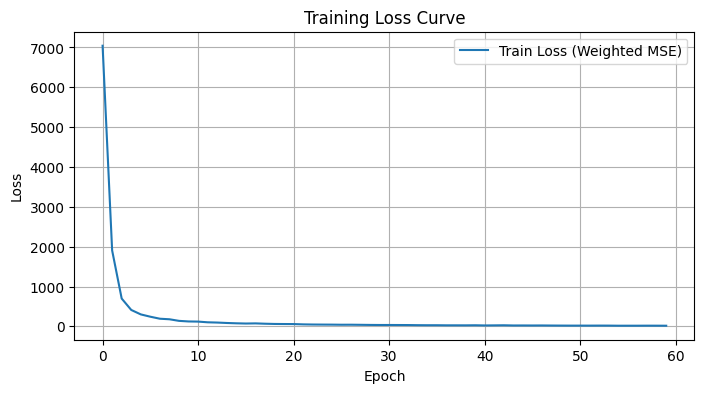

In [5]:
# Training Parameters
EPOCHS = 60
BATCH_SIZE = 4
LEARNING_RATE = 1e-4 # Better for fine-tuning pre-trained HRNet

# Hardware Optimization
# Enable CUDNN benchmark for faster training if input sizes remain constant
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False

# DataLoader - Pin memory and use multiple workers for faster data loading
num_workers = min(4, os.cpu_count() or 1) # Default to 4 or max available cores
train_loader = DataLoader(
    dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    drop_last=False, 
    num_workers=num_workers,
    pin_memory=torch.cuda.is_available() # Speeds up host to device transfers
)

# Optimizer & Loss
class WeightedMSELoss(nn.Module):
    def __init__(self):
        super(WeightedMSELoss, self).__init__()
        self.criterion = nn.MSELoss(reduction='none')

    def forward(self, output, target, target_weight):
        batch_size = output.size(0)
        num_joints = output.size(1)
        
        # heatmap shape: (B, N, H, W)
        heatmaps_pred = output.reshape((batch_size, num_joints, -1)).split(1, 1)
        heatmaps_gt = target.reshape((batch_size, num_joints, -1)).split(1, 1)

        loss = 0.0
        for idx in range(num_joints):
            heatmap_pred = heatmaps_pred[idx].squeeze(1)
            heatmap_gt = heatmaps_gt[idx].squeeze(1)
            
            # Using sum(dim=1) prevents the spatial gradients from disappearing
            # due to mostly 0s in the heatmaps
            weight = target_weight[:, idx]
            loss += 0.5 * self.criterion(heatmap_pred, heatmap_gt).sum(dim=1) * weight.squeeze(-1)

        return loss.mean()

criterion = WeightedMSELoss().to(device)

# Using standard Adam or AdamW with small weight decay 
# to prevent weights from vanishing due to tiny target errors
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# Training Loop
train_losses = []

print("Starting training...")

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0
    
    for batch_idx, (images, heatmaps_gt, target_weight, meta) in enumerate(train_loader):
        # Move tensors to GPU asynchronously (non-blocking) out of pinned memory
        images = images.to(device, non_blocking=True)
        heatmaps_gt = heatmaps_gt.to(device, non_blocking=True)
        target_weight = target_weight.to(device, non_blocking=True)
        
        # Forward pass
        heatmaps_pred = model(images)
        
        # Computes masked MSE loss. Replaced * 1000 with a well-scaled sum in the loss function instead.
        loss = criterion(heatmaps_pred, heatmaps_gt, target_weight)
        
        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    scheduler.step(avg_loss)
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}] - Loss: {avg_loss:.4f} | LR: {optimizer.param_groups[0]['lr']:.8f}")

print("Training finished!")

# Plot training loss
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train Loss (Weighted MSE)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.grid()
plt.legend()
plt.show()

In [8]:
# Save the Model and run Inference on a new image

import os
import cv2

# 1. Save the model weights
save_path = "models/hrnet_finetuned_60epoch.pth"
os.makedirs("models", exist_ok=True)
torch.save(model.state_dict(), save_path)
print(f"✅ Model saved successfully to: {save_path}")


✅ Model saved successfully to: models/hrnet_finetuned_60epoch.pth


3.35625


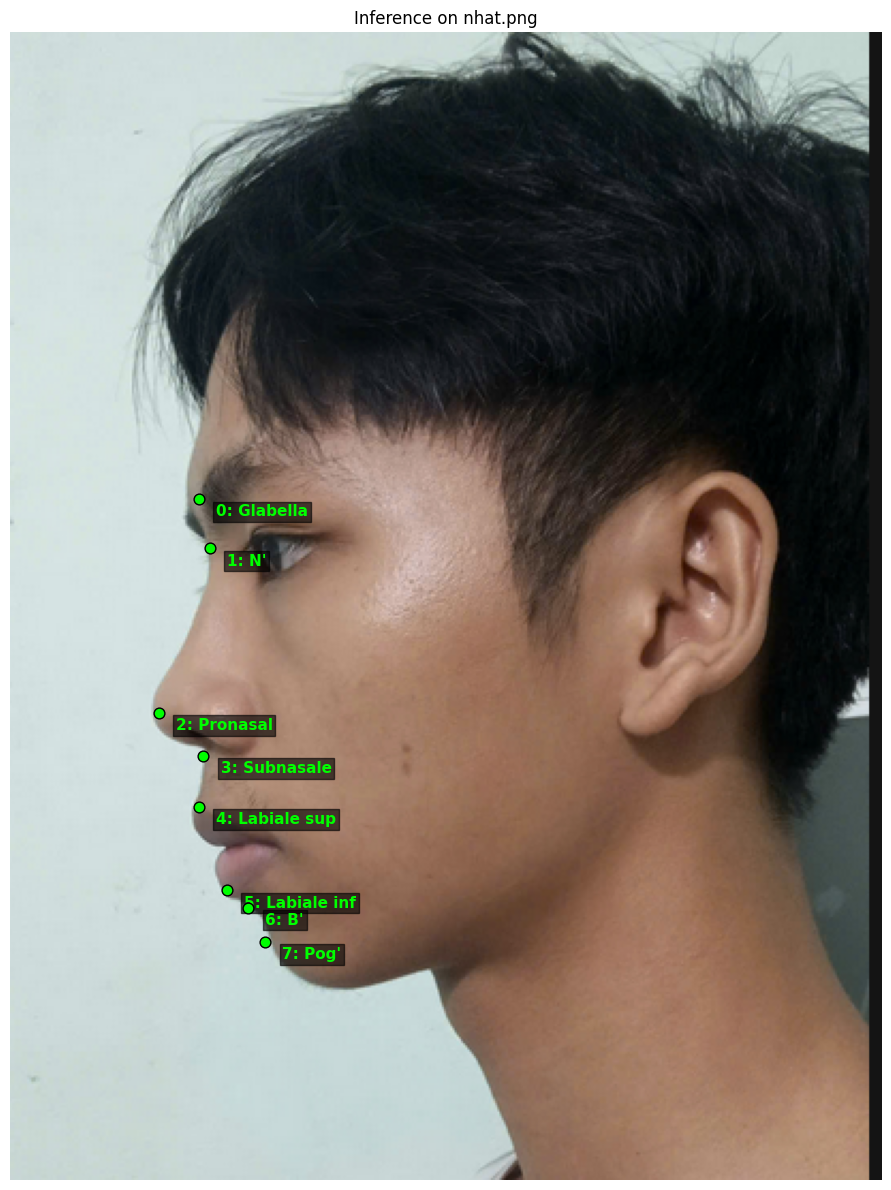

In [10]:
# 2. Run Inference on Unseen Image exactly like the Training Pipeline

test_image_path = "data/test/nhat.png"

if not os.path.exists(test_image_path):
    print(f"⚠️ Image not found at {test_image_path}")
else:
    # Load and prep image
    image = cv2.imread(test_image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # We don't have a specific bounding box for unseen inference, so we assume 
    # the whole image is the face bounding box to align with our math
    orig_h, orig_w = image_rgb.shape[:2]
    center_w = orig_w / 2.0
    center_h = orig_h / 2.0
    center = torch.Tensor([center_w, center_h])
    scale = max(orig_w, orig_h) / 200.0 * 1.25

    # Apply identical affine crop logic
    img_crop = crop_v2(image_rgb, center.numpy(), scale, [512, 512], rot=0)
    
    # Convert to tensor & normalize
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    
    img_crop = img_crop.astype(np.float32)
    img_crop = (img_crop / 255.0 - mean) / std
    img_crop = img_crop.transpose([2, 0, 1])
    img_tensor = torch.from_numpy(img_crop).unsqueeze(0).to(device)
    
    # Model predict
    model.eval()
    with torch.no_grad():
        pred_hms = model(img_tensor)
        
        # The official decode_preds applies Taylor sub-pixel expansion and inversely 
        # transforms from the Heatmap space directly back to the original image!
        # Parameter expecting sformat: decode_preds(output, center, scale, resolution)
        # res=[128, 128] because our heatmap size is (128, 128)
        pred_coords = decode_preds(pred_hms.cpu(), [center], [scale], [128, 128])
    
    # Squeeze batch size out
    pred_coords = pred_coords[0].numpy()
    
    # Labels for visualization
    labels = [
        "Glabella", "N'", "Pronasal", "Subnasale",
        "Labiale sup", "Labiale inf", "B'", "Pog'"
    ]
    
    # Plotting
    fig, ax = plt.subplots(1, 1, figsize=(10, 12))
    ax.imshow(image_rgb)
    ax.set_title(f"Inference on {os.path.basename(test_image_path)}")
    
    # Sub-pixel precise mapping directly onto original uncropped image axis!
    for i, (orig_x, orig_y) in enumerate(pred_coords):
        ax.scatter(orig_x, orig_y, c='lime', marker='o', s=60, edgecolors='black', zorder=5)
        ax.text(orig_x + 8, orig_y + 8, f"{i}: {labels[i]}", color='lime', 
                fontsize=11, fontweight='bold', bbox=dict(facecolor='black', alpha=0.6, pad=2))
        
    plt.axis('off')
    plt.tight_layout()
    plt.show()